# Brain Tumor MRI Classification
**Classes:** Glioma | Meningioma | Pituitary | No Tumor  
**Dataset structure expected:**
```
dataset/
  Training/
    glioma/cancer that grows in the brain/spinal cord from glial cells (the "support cells" of the brain). Most dangerous of the three tumor types.
    meningioma/grows in the meninges, the protective membrane that wraps around your brain. Usually slow growing and less aggressive.
    notumor/healthy brain MRI scan, nothing abnormal.
    pituitary/grows in the pituitary gland, a tiny gland at the base of your brain that controls hormones. Often treatable.
  Testing/
    glioma/
    ...
```

In [42]:
import torch
import torch.nn as nn
import torchvision.transforms as Transforms
import torchvision.datasets as Datasets
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [43]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(device)

mps


## 1. Data Loading
`ImageFolder` automatically assigns labels based on subfolder names — no manual labeling needed.

In [44]:
# Put your Training and Testing folders next to this notebook
train_dir = '/Users/arhaan/Downloads/archive-1/Training'
test_dir  = '/Users/arhaan/Downloads/archive-1/Testing'

In [45]:
my_transform = Transforms.Compose([
    Transforms.Resize((224, 224)),          # ResNet18 expects 224x224
    Transforms.ToTensor(),
    Transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [46]:
import os
print(os.getcwd())
print(os.listdir('.'))

/Users/arhaan/Documents/Codes/softwarelab/python
['brain_tumor_classification.ipynb']


In [47]:
import os
print(os.listdir('/Users/arhaan/Downloads/archive-1'))

['.DS_Store', 'Training', 'Testing']


In [48]:
# ImageFolder reads subfolders as class labels automatically
full_train_dataset = Datasets.ImageFolder(root=train_dir, transform=my_transform)
test_dataset       = Datasets.ImageFolder(root=test_dir,  transform=my_transform)

print("Classes:", full_train_dataset.classes)   # ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Train size:", len(full_train_dataset))
print("Test size:",  len(test_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 5600
Test size: 1600


In [49]:
# Split training into train + validation (80/20) — pure PyTorch, no sklearn
val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Train: {train_size} | Val: {val_size}")

Train: 4480 | Val: 1120


In [50]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [51]:
model = models.resnet18(weights='IMAGENET1K_V1')

# Replace final layer: 512 → 4 classes
model.fc = nn.Linear(512, 4)

model = model.to(device)
print(model)
print(model.fc)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [52]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 3. Training Loop

In [ ]:
num_epochs = 20

train_accuracies = []
train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    #Training
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # shape: (batch, 4)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    #Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            val_loss += criterion(outputs, labels).item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)


    print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {avg_train_loss:.4f}  Val Loss: {avg_val_loss:.4f}")

Epoch 1/20  Train Loss: 0.3545  Val Loss: 0.2742
Epoch 2/20  Train Loss: 0.1675  Val Loss: 0.3861
Epoch 3/20  Train Loss: 0.1131  Val Loss: 0.2017
Epoch 4/20  Train Loss: 0.0858  Val Loss: 0.1757
Epoch 5/20  Train Loss: 0.0651  Val Loss: 0.3307
Epoch 6/20  Train Loss: 0.0612  Val Loss: 0.1568
Epoch 7/20  Train Loss: 0.0474  Val Loss: 0.2422
Epoch 8/20  Train Loss: 0.0872  Val Loss: 0.1820
Epoch 9/20  Train Loss: 0.0483  Val Loss: 0.0888
Epoch 10/20  Train Loss: 0.0280  Val Loss: 0.2274
Epoch 11/20  Train Loss: 0.0156  Val Loss: 0.1784
Epoch 12/20  Train Loss: 0.0403  Val Loss: 0.1564
Epoch 13/20  Train Loss: 0.0310  Val Loss: 0.3942
Epoch 14/20  Train Loss: 0.0436  Val Loss: 0.2443
Epoch 15/20  Train Loss: 0.0207  Val Loss: 0.1647
Epoch 16/20  Train Loss: 0.0091  Val Loss: 0.1126
Epoch 17/20  Train Loss: 0.0096  Val Loss: 0.2095
Epoch 18/20  Train Loss: 0.0207  Val Loss: 0.3094
Epoch 19/20  Train Loss: 0.0266  Val Loss: 0.1259
Epoch 20/20  Train Loss: 0.0156  Val Loss: 0.1551


## 4. Plot Losses

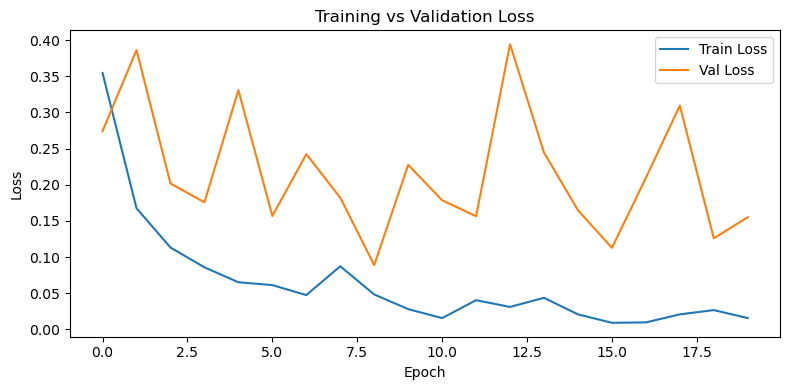

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluation — Manual Accuracy 
`torch.argmax` picks the class with the highest score, then we compare with the true label.

In [37]:
def evaluate(loader, loader_name='Test'):
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs   = model(images)               # raw scores per class
            predicted = torch.argmax(outputs, dim=1) # class with highest score

            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    accuracy = correct / total * 100
    print(f"{loader_name} Accuracy: {accuracy:.2f}%  ({correct}/{total})")
    return accuracy

In [38]:
evaluate(val_loader,  'Validation')
evaluate(test_loader, 'Test')

Validation Accuracy: 96.61%  (1082/1120)
Test Accuracy: 92.88%  (1486/1600)


92.875

In [39]:
def per_class_accuracy(loader):
    class_names = full_train_dataset.classes   # ['glioma', 'meningioma', 'notumor', 'pituitary']
    correct_per_class = torch.zeros(4)
    total_per_class   = torch.zeros(4)

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            predicted = torch.argmax(outputs, dim=1)

            for c in range(4):
                mask = (labels == c)                         # only look at samples of class c
                correct_per_class[c] += (predicted[mask] == labels[mask]).sum().item()
                total_per_class[c]   += mask.sum().item()

    for c in range(4):
        acc = correct_per_class[c] / total_per_class[c] * 100
        print(f"  {class_names[c]:<14} {acc:.2f}%")

In [40]:
print("Per-class accuracy on Test set:")
per_class_accuracy(test_loader)

Per-class accuracy on Test set:
  glioma         79.25%
  meningioma     93.75%
  notumor        99.25%
  pituitary      99.25%


## 7. Visualise Sample Predictions

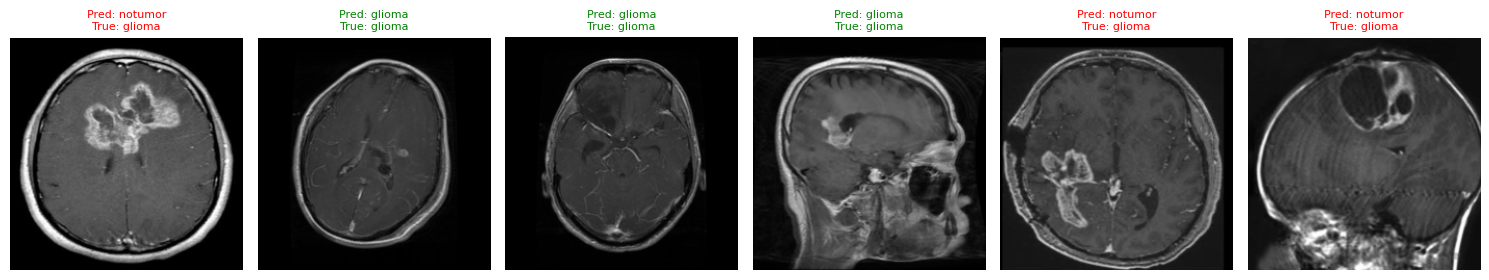

In [41]:
def show_predictions(loader, num_images=6):
    class_names = full_train_dataset.classes
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    model.eval()
    with torch.no_grad():
        outputs   = model(images)
        predicted = torch.argmax(outputs, dim=1)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        img = images[i].cpu().permute(1, 2, 0)  # C,H,W → H,W,C
        img = img * 0.5 + 0.5                   # undo normalize
        axes[i].imshow(img.clamp(0, 1))
        axes[i].axis('off')

        pred  = class_names[predicted[i]]
        truth = class_names[labels[i]]
        color = 'green' if pred == truth else 'red'
        axes[i].set_title(f'Pred: {pred}\nTrue: {truth}', color=color, fontsize=8)

    plt.tight_layout()
    plt.show()

show_predictions(test_loader)